In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")
X = train_df.drop(
    "label", axis=1
).values
Y = train_df["label"].values

X_test = test_df.values
train_df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
X = X.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0
Y = to_categorical(Y, num_classes=10)

In [5]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=np.argmax(Y,axis=1))
print("Training samples:",X_train.shape[0])
print("Validation samples:",X_val.shape[0])


Training samples: 33600
Validation samples: 8400


In [6]:
model = Sequential([
    Dense(512, activation='relu',input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history=model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-14 16:32:18.367682: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8726 - loss: 0.4150 - val_accuracy: 0.9520 - val_loss: 0.1757
Epoch 2/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9419 - loss: 0.1894 - val_accuracy: 0.9613 - val_loss: 0.1276
Epoch 3/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9554 - loss: 0.1445 - val_accuracy: 0.9665 - val_loss: 0.1071
Epoch 4/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9641 - loss: 0.1183 - val_accuracy: 0.9694 - val_loss: 0.1039
Epoch 5/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9696 - loss: 0.0991 - val_accuracy: 0.9701 - val_loss: 0.1044
Epoch 6/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9734 - loss: 0.0827 - val_accuracy: 0.9724 - val_loss: 0.1020
Epoch 7/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9748 - loss: 0.0790 - val_accuracy: 0.9723 - val_loss: 0.0998
Epoch 8/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9759 - loss: 0.0737 - val_accu

In [7]:
loss,accuracy=model.evaluate(X_val,Y_val,verbose=0)
print(f"\nValidation Loss : {loss:.4f}")
print(f"Validation accuracy : {accuracy:.4f}")



Validation Loss : 0.0839
Validation accuracy : 0.9780


In [8]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


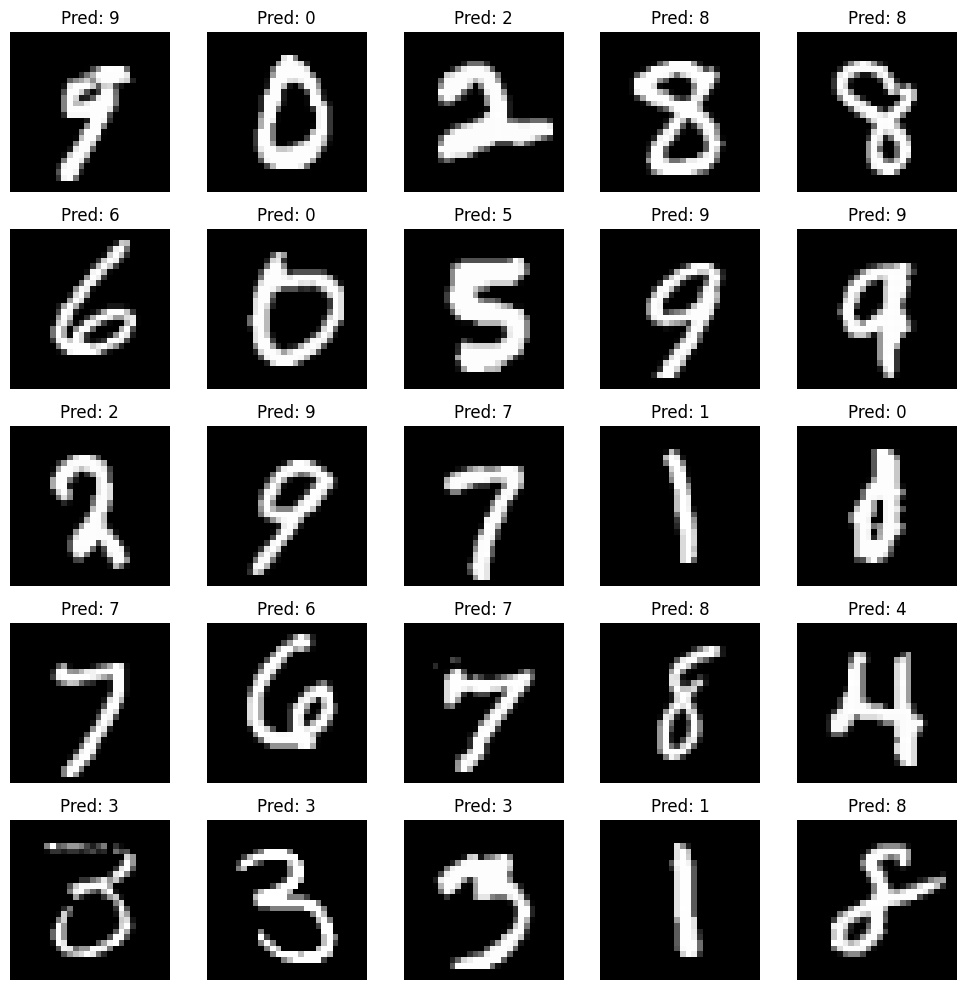

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Number of images to display
num_images = 25

# Randomly select indices
indices = np.random.choice(len(X_test), num_images, replace=False)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)

    # Reshape 784 pixels into 28x28 image
    image = X_test[idx].reshape(28, 28)

    plt.imshow(image, cmap='gray')
    plt.title(f"Pred: {predicted_labels[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# ----------------------------------------------------
# Create Submission File
# ----------------------------------------------------
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predicted_labels)+1),
    "Label": predicted_labels
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully!")

submission.csv saved successfully!
